In [1]:
import pandas as pd
file_path = 'Mobiles Dataset (2025).csv'

# Try reading the CSV with 'latin1' encoding
df = pd.read_csv(file_path, encoding='latin1')
df

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
0,Apple,iPhone 16 128GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 224,999","INR 79,999","CNY 5,799",USD 799,"AED 2,799",2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 234,999","INR 84,999","CNY 6,099",USD 849,"AED 2,999",2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 244,999","INR 89,999","CNY 6,499",USD 899,"AED 3,199",2024
3,Apple,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 249,999","INR 89,999","CNY 6,199",USD 899,"AED 3,199",2024
4,Apple,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 259,999","INR 94,999","CNY 6,499",USD 949,"AED 3,399",2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
925,Poco,Pad 5G 128GB,571g,8GB,8MP,8MP,Snapdragon 7s Gen 2,"10,000mAh",12.1 inches,"PKR 66,220","INR 23,999","CNY 2,099",USD 280,"AED 1,029",2024
926,Poco,Pad 5G 256GB,571g,8GB,8MP,8MP,Snapdragon 7s Gen 2,"10,000mAh",12.1 inches,"PKR 71,220","INR 25,999","CNY 2,299",USD 300,"AED 1,099",2024
927,Samsung,Galaxy Z Fold6 256GB,239g,12GB,"10MP, 4MP (UDC)",50MP,Snapdragon 8 Gen 3,4400mAh,7.6 inches,"PKR 604,999","INR 164,999","¥13,999","USD 1,899","AED 7,199",2024
928,Samsung,Galaxy Z Fold6 512GB,239g,12GB,"10MP, 4MP (UDC)",50MP,Snapdragon 8 Gen 3,4400mAh,7.6 inches,"PKR 544,999","INR 176,999","CNY 15,999",USD 1719,"AED 7,699",2024


In [2]:
# Cellule 3 – Infos générales sur le dataset

print("✅ Dimensions :", df.shape)
print("\n✅ Colonnes :")
print(df.columns)

print("\n✅ Aperçu des types :")
print(df.dtypes)

print("\n✅ Aperçu des premières lignes :")
display(df.head())


✅ Dimensions : (930, 15)

✅ Colonnes :
Index(['Company Name', 'Model Name', 'Mobile Weight', 'RAM', 'Front Camera',
       'Back Camera', 'Processor', 'Battery Capacity', 'Screen Size',
       'Launched Price (Pakistan)', 'Launched Price (India)',
       'Launched Price (China)', 'Launched Price (USA)',
       'Launched Price (Dubai)', 'Launched Year'],
      dtype='object')

✅ Aperçu des types :
Company Name                 object
Model Name                   object
Mobile Weight                object
RAM                          object
Front Camera                 object
Back Camera                  object
Processor                    object
Battery Capacity             object
Screen Size                  object
Launched Price (Pakistan)    object
Launched Price (India)       object
Launched Price (China)       object
Launched Price (USA)         object
Launched Price (Dubai)       object
Launched Year                 int64
dtype: object

✅ Aperçu des premières lignes :


,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
0,Apple,iPhone 16 128GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 224,999","INR 79,999","CNY 5,799",USD 799,"AED 2,799",2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 234,999","INR 84,999","CNY 6,099",USD 849,"AED 2,999",2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 244,999","INR 89,999","CNY 6,499",USD 899,"AED 3,199",2024
3,Apple,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 249,999","INR 89,999","CNY 6,199",USD 899,"AED 3,199",2024
4,Apple,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 259,999","INR 94,999","CNY 6,499",USD 949,"AED 3,399",2024


In [3]:
df = df.drop(columns=["Launched Price (Pakistan)","Launched Price (India)","Launched Price (China)","Launched Price (Dubai)"])


In [4]:
# Cellule 4 – Fonctions utilitaires pour nettoyer les colonnes texte -> numérique

import re

def to_numeric_generic(x):
    """
    Garder uniquement les chiffres et le point décimal.
    Gère les formats : '174g', '3,600mAh', '6.1 inches', 'USD 799', 'PKR 224,999', etc.
    """
    if pd.isna(x):
        return np.nan
    s = str(x)
    s = s.replace(',', '')            # enlever les séparateurs de milliers
    s = re.sub(r'[^0-9\.]', '', s)    # garder digits + '.'
    if s == '':
        return np.nan
    return pd.to_numeric(s, errors='coerce')


def extract_ram_gb(x):
    """
    Exemple '6GB' -> 6
    """
    if pd.isna(x):
        return np.nan
    s = str(x)
    s = re.findall(r'\d+', s)
    return pd.to_numeric(s[0], errors='coerce') if s else np.nan


def extract_camera_mp(x):
    """
    Exemple '48MP' -> 48
    """
    if pd.isna(x):
        return np.nan
    s = str(x)
    s = re.findall(r'\d+', s)
    return pd.to_numeric(s[0], errors='coerce') if s else np.nan


In [5]:
df["Mobile_Weight_g"]   = df["Mobile Weight"].apply(to_numeric_generic)
df["RAM_GB"]            = df["RAM"].apply(extract_ram_gb)
df["FrontCam_MP"]       = df["Front Camera"].apply(extract_camera_mp)
df["BackCam_MP"]        = df["Back Camera"].apply(extract_camera_mp)
df["Battery_mAh"]       = df["Battery Capacity"].apply(to_numeric_generic)
df["Screen_inch"]       = df["Screen Size"].apply(to_numeric_generic)
df["Price_USD"]   = df["Launched Price (USA)"].apply(to_numeric_generic)

In [6]:
df = df.drop(columns=["Mobile Weight","RAM","Front Camera","Back Camera","Battery Capacity","Screen Size","Launched Price (USA)"])

In [7]:
# Cellule 3 – Infos générales sur le dataset

print("✅ Dimensions :", df.shape)
print("\n✅ Colonnes :")
print(df.columns)

print("\n✅ Aperçu des types :")
print(df.dtypes)

print("\n✅ Aperçu des premières lignes :")
display(df.head())

✅ Dimensions : (930, 11)

✅ Colonnes :
Index(['Company Name', 'Model Name', 'Processor', 'Launched Year',
       'Mobile_Weight_g', 'RAM_GB', 'FrontCam_MP', 'BackCam_MP', 'Battery_mAh',
       'Screen_inch', 'Price_USD'],
      dtype='object')

✅ Aperçu des types :
Company Name        object
Model Name          object
Processor           object
Launched Year        int64
Mobile_Weight_g    float64
RAM_GB               int64
FrontCam_MP          int64
BackCam_MP           int64
Battery_mAh          int64
Screen_inch        float64
Price_USD          float64
dtype: object

✅ Aperçu des premières lignes :


,Company Name,Model Name,Processor,Launched Year,Mobile_Weight_g,RAM_GB,FrontCam_MP,BackCam_MP,Battery_mAh,Screen_inch,Price_USD
0,Apple,iPhone 16 128GB,A17 Bionic,2024,174.0,6,12,48,3600,6.1,799.0
1,Apple,iPhone 16 256GB,A17 Bionic,2024,174.0,6,12,48,3600,6.1,849.0
2,Apple,iPhone 16 512GB,A17 Bionic,2024,174.0,6,12,48,3600,6.1,899.0
3,Apple,iPhone 16 Plus 128GB,A17 Bionic,2024,203.0,6,12,48,4200,6.7,899.0
4,Apple,iPhone 16 Plus 256GB,A17 Bionic,2024,203.0,6,12,48,4200,6.7,949.0


In [8]:
df.select_dtypes(include=["number"]).describe().T


,count,mean,std,min,25%,50%,75%,max
Launched Year,930.0,2022.193548,1.862080,2014.0,2021.0,2023.00,2024.00,2025.0
Mobile_Weight_g,930.0,228.267097,105.432503,135.0,185.0,194.00,208.00,732.0
RAM_GB,930.0,7.783871,3.181885,1.0,6.0,8.00,8.00,16.0
FrontCam_MP,930.0,18.153763,11.992239,2.0,8.0,16.00,32.00,60.0
BackCam_MP,930.0,46.762366,31.072063,5.0,16.0,50.00,50.00,200.0
Battery_mAh,930.0,5026.163441,1355.548264,2000.0,4402.5,5000.00,5091.25,11200.0
Screen_inch,926.0,7.085238,1.536834,5.0,6.5,6.67,6.78,14.6
Price_USD,930.0,625.515763,1347.561211,79.0,250.0,449.00,849.00,39622.0


In [9]:
# Cellule 6 – Valeurs manquantes et doublons

print("✅ Nombre de valeurs manquantes par colonne (avant nettoyage) :")
display(df.isna().sum())

print("\n✅ Nombre de doublons (lignes identiques sur toutes les colonnes) :",
      df.duplicated().sum())




✅ Nombre de valeurs manquantes par colonne (avant nettoyage) :


Company Name       0
Model Name         0
Processor          0
Launched Year      0
Mobile_Weight_g    0
RAM_GB             0
FrontCam_MP        0
BackCam_MP         0
Battery_mAh        0
Screen_inch        4
Price_USD          0
dtype: int64


✅ Nombre de doublons (lignes identiques sur toutes les colonnes) : 15


In [10]:
# Trouver les doublons (toutes colonnes)
duplicated_rows = df[df.duplicated(keep=False)]

# Afficher les doublons
duplicated_rows


,Company Name,Model Name,Processor,Launched Year,Mobile_Weight_g,RAM_GB,FrontCam_MP,BackCam_MP,Battery_mAh,Screen_inch,Price_USD
344,Oppo,A3 128GB,Snapdragon 6s 4G Gen 1,2024,186.0,4,5,50,5000,6.70,399.0
347,Oppo,A3 128GB,Snapdragon 6s 4G Gen 1,2024,186.0,4,5,50,5000,6.70,399.0
423,Oppo,K11x 128GB,Qualcomm Snapdragon 695,2023,195.0,8,16,108,5000,6.72,199.0
424,Oppo,K11x 256GB,Qualcomm Snapdragon 695,2023,195.0,12,16,108,5000,6.72,229.0
425,Oppo,K10x 128GB,Qualcomm Snapdragon 695,2022,195.0,6,16,64,5000,6.59,199.0
426,Oppo,K10x 256GB,Qualcomm Snapdragon 695,2022,195.0,8,16,64,5000,6.59,229.0
427,Oppo,K10 5G 128GB,MediaTek Dimensity 8000-Max,2022,205.0,8,16,64,5000,6.59,249.0
428,Oppo,K9x 128GB,MediaTek Dimensity 810,2021,194.0,6,16,64,5000,6.50,199.0
429,Oppo,K9x 256GB,MediaTek Dimensity 810,2021,194.0,8,16,64,5000,6.50,229.0
430,Oppo,K9 Pro 5G 128GB,MediaTek Dimensity 1200,2021,180.0,8,16,64,4500,6.43,299.0


In [11]:
# Lignes contenant au moins une valeur manquante
missing_rows = df[df.isna().any(axis=1)]

# Afficher les lignes
missing_rows


,Company Name,Model Name,Processor,Launched Year,Mobile_Weight_g,RAM_GB,FrontCam_MP,BackCam_MP,Battery_mAh,Screen_inch,Price_USD
568,Motorola,Razr 128GB,Snapdragon 8+ Gen 1,2023,192.0,8,32,50,3500,NaN,999.0
569,Motorola,Razr 256GB,Snapdragon 8+ Gen 1,2023,192.0,12,32,50,3500,NaN,1099.0
598,Motorola,Razr 50 Ultra 512GB,Snapdragon 8+ Gen 1,2024,189.0,12,32,50,4000,NaN,1199.0
599,Motorola,Razr 50 256GB,Snapdragon 7 Gen 1,2024,188.0,8,32,50,3800,NaN,999.0


In [12]:
# Optionnel : supprimer les doublons exacts
df = df.drop_duplicates().reset_index(drop=True)
print("✅ Nouvelle forme après suppression des doublons :", df.shape)

✅ Nouvelle forme après suppression des doublons : (915, 11)


In [13]:
# Lignes contenant au moins une valeur manquante
missing_rows = df[df.isna().any(axis=1)]

# Afficher les lignes
missing_rows


,Company Name,Model Name,Processor,Launched Year,Mobile_Weight_g,RAM_GB,FrontCam_MP,BackCam_MP,Battery_mAh,Screen_inch,Price_USD
554,Motorola,Razr 128GB,Snapdragon 8+ Gen 1,2023,192.0,8,32,50,3500,NaN,999.0
555,Motorola,Razr 256GB,Snapdragon 8+ Gen 1,2023,192.0,12,32,50,3500,NaN,1099.0
584,Motorola,Razr 50 Ultra 512GB,Snapdragon 8+ Gen 1,2024,189.0,12,32,50,4000,NaN,1199.0
585,Motorola,Razr 50 256GB,Snapdragon 7 Gen 1,2024,188.0,8,32,50,3800,NaN,999.0


In [14]:
df.loc[[554, 555, 584, 585], "Screen_inch"] = 6.9


In [15]:
df

,Company Name,Model Name,Processor,Launched Year,Mobile_Weight_g,RAM_GB,FrontCam_MP,BackCam_MP,Battery_mAh,Screen_inch,Price_USD
0,Apple,iPhone 16 128GB,A17 Bionic,2024,174.0,6,12,48,3600,6.1,799.0
1,Apple,iPhone 16 256GB,A17 Bionic,2024,174.0,6,12,48,3600,6.1,849.0
2,Apple,iPhone 16 512GB,A17 Bionic,2024,174.0,6,12,48,3600,6.1,899.0
3,Apple,iPhone 16 Plus 128GB,A17 Bionic,2024,203.0,6,12,48,4200,6.7,899.0
4,Apple,iPhone 16 Plus 256GB,A17 Bionic,2024,203.0,6,12,48,4200,6.7,949.0
...,...,...,...,...,...,...,...,...,...,...,...
910,Poco,Pad 5G 128GB,Snapdragon 7s Gen 2,2024,571.0,8,8,8,10000,12.1,280.0
911,Poco,Pad 5G 256GB,Snapdragon 7s Gen 2,2024,571.0,8,8,8,10000,12.1,300.0
912,Samsung,Galaxy Z Fold6 256GB,Snapdragon 8 Gen 3,2024,239.0,12,10,50,4400,7.6,1899.0
913,Samsung,Galaxy Z Fold6 512GB,Snapdragon 8 Gen 3,2024,239.0,12,10,50,4400,7.6,1719.0


In [16]:
# Cellule 6 – Valeurs manquantes et doublons

print("✅ Nombre de valeurs manquantes par colonne (après nettoyage) :")
display(df.isna().sum())

print("\n✅ Nombre de doublons (lignes identiques sur toutes les colonnes) :",
      df.duplicated().sum())



✅ Nombre de valeurs manquantes par colonne (après nettoyage) :


Company Name       0
Model Name         0
Processor          0
Launched Year      0
Mobile_Weight_g    0
RAM_GB             0
FrontCam_MP        0
BackCam_MP         0
Battery_mAh        0
Screen_inch        0
Price_USD          0
dtype: int64


✅ Nombre de doublons (lignes identiques sur toutes les colonnes) : 0


In [17]:
df

,Company Name,Model Name,Processor,Launched Year,Mobile_Weight_g,RAM_GB,FrontCam_MP,BackCam_MP,Battery_mAh,Screen_inch,Price_USD
0,Apple,iPhone 16 128GB,A17 Bionic,2024,174.0,6,12,48,3600,6.1,799.0
1,Apple,iPhone 16 256GB,A17 Bionic,2024,174.0,6,12,48,3600,6.1,849.0
2,Apple,iPhone 16 512GB,A17 Bionic,2024,174.0,6,12,48,3600,6.1,899.0
3,Apple,iPhone 16 Plus 128GB,A17 Bionic,2024,203.0,6,12,48,4200,6.7,899.0
4,Apple,iPhone 16 Plus 256GB,A17 Bionic,2024,203.0,6,12,48,4200,6.7,949.0
...,...,...,...,...,...,...,...,...,...,...,...
910,Poco,Pad 5G 128GB,Snapdragon 7s Gen 2,2024,571.0,8,8,8,10000,12.1,280.0
911,Poco,Pad 5G 256GB,Snapdragon 7s Gen 2,2024,571.0,8,8,8,10000,12.1,300.0
912,Samsung,Galaxy Z Fold6 256GB,Snapdragon 8 Gen 3,2024,239.0,12,10,50,4400,7.6,1899.0
913,Samsung,Galaxy Z Fold6 512GB,Snapdragon 8 Gen 3,2024,239.0,12,10,50,4400,7.6,1719.0


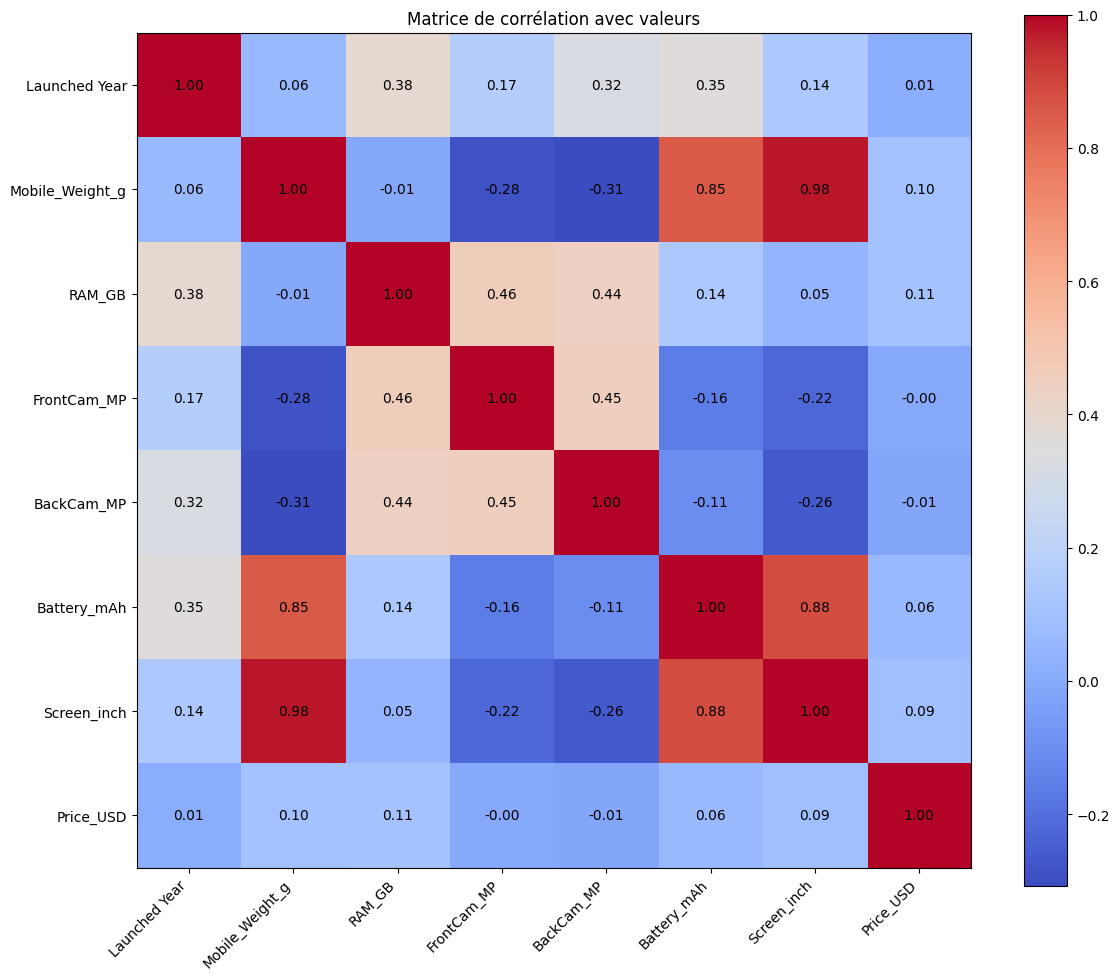

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Sélection des colonnes numériques
num_df = df.select_dtypes(include="number")

# Matrice de corrélation
corr = num_df.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

# Ajout des labels
cols = num_df.columns
plt.xticks(range(len(cols)), cols, rotation=45, ha='right')
plt.yticks(range(len(cols)), cols)

# Ajout des valeurs dans chaque cellule
for i in range(len(cols)):
    for j in range(len(cols)):
        value = corr.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha='center', va='center', color="black")

plt.title("Matrice de corrélation avec valeurs")
plt.tight_layout()
plt.show()


---
## Section Clustering

Objectif : regrouper les téléphones selon leurs **caractéristiques techniques** (indépendamment de la marque et du prix), pour identifier les modèles aux specs proches mais à des prix différents.

### Stratégie de pondération
On réduit fortement l'influence du **poids physique** et de la **taille d'écran** (très faible variance utile) et on booste **RAM, batterie et caméras** qui représentent les vrais critères de performance.

| Feature | Poids |
|---|---|
| Mobile_Weight_g | 0.0 (ignoré) |
| RAM_GB | 1.5 |
| FrontCam_MP | 0.8 |
| BackCam_MP | 1.2 |
| Battery_mAh | 1.3 |
| Screen_inch | 0.4 |

In [19]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# --- Pondérations optimisées ---
# On retire Mobile_Weight_g (poids=0) car non pertinent pour les specs
# On mise sur RAM, batterie, caméras
FEATURES = ['Mobile_Weight_g', 'RAM_GB', 'FrontCam_MP', 'BackCam_MP', 'Battery_mAh', 'Screen_inch']
WEIGHTS  = np.array([0.1,          1.5,    1.2,          1.2,          1.3,           0.5])

X_raw = df[FEATURES].copy()

# Imputation médiane
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X_raw)

# Application des poids AVANT la standardisation
X_weighted = X_imp * WEIGHTS

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_weighted)

print(f"Données prêtes : {X_scaled.shape[0]} téléphones, {X_scaled.shape[1]} features pondérées")

Données prêtes : 915 téléphones, 6 features pondérées


### Benchmark de tous les modèles de clustering

On teste et compare :
- **KMeans** (k=3 à 7) – rapide, clusters sphériques
- **Agglomerative / Ward** (k=3 à 7) – meilleure forme de clusters, hiérarchique
- **DBSCAN** (plusieurs eps) – détecte outliers, pas besoin de fixer k
- **Birch** (k=3 à 6) – adapté aux grands datasets
- **SpectralClustering** (k=3 à 5) – bon sur structures non-convexes
- **GMM** (k=3 à 6) – probabiliste, souple

Métriques utilisées :
- **Silhouette** (↑ mieux, max=1)
- **Davies-Bouldin** (↓ mieux, min=0)
- **Calinski-Harabasz** (↑ mieux)

In [20]:

from sklearn.cluster import (KMeans, AgglomerativeClustering, DBSCAN,
                             Birch, SpectralClustering)
from sklearn.mixture import GaussianMixture
import warnings
warnings.filterwarnings('ignore')

def score_model(X, labels):
    """Calcule 3 métriques de qualité de clustering."""
    mask = labels != -1  # Ignorer les outliers DBSCAN
    if len(set(labels[mask])) < 2:
        return -1, 99, -1
    sil = silhouette_score(X[mask], labels[mask])
    db  = davies_bouldin_score(X[mask], labels[mask])
    ch  = calinski_harabasz_score(X[mask], labels[mask])
    return sil, db, ch

results = []
K_RANGE = range(4, 8)

# --- KMeans ---
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbs = km.fit_predict(X_scaled)
    s, d, c = score_model(X_scaled, lbs)
    results.append({'Modèle': f'KMeans k={k}', 'Silhouette↑': s, 'Davies-Bouldin↓': d,
                    'Calinski-Harabasz↑': c, 'n_clusters': k, 'n_outliers': 0,
                    'labels': lbs, 'eligible': True})

# --- Agglomerative (Ward) ---
for k in K_RANGE:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    lbs = agg.fit_predict(X_scaled)
    s, d, c = score_model(X_scaled, lbs)
    results.append({'Modèle': f'Agglomerative(ward) k={k}', 'Silhouette↑': s,
                    'Davies-Bouldin↓': d, 'Calinski-Harabasz↑': c,
                    'n_clusters': k, 'n_outliers': 0, 'labels': lbs, 'eligible': True})

# --- DBSCAN : affiché pour info mais NON éligible ---
# Raison : génère trop de micro-clusters (>15) et des outliers non classifiés
# → inutilisable pour une appli de recommandation
for eps in [0.6, 0.7, 0.8, 0.9, 1.0, 1.2]:
    db_model = DBSCAN(eps=eps, min_samples=8)
    lbs = db_model.fit_predict(X_scaled)
    n_c = len(set(lbs)) - (1 if -1 in lbs else 0)
    n_o = (lbs == -1).sum()
    if n_c < 2:
        continue
    s, dbs, c = score_model(X_scaled, lbs)
    results.append({'Modèle': f'DBSCAN eps={eps}', 'Silhouette↑': s,
                    'Davies-Bouldin↓': dbs, 'Calinski-Harabasz↑': c,
                    'n_clusters': n_c, 'n_outliers': n_o, 'labels': lbs,
                    'eligible': False})  # ❌ exclu : trop de clusters, outliers non gérables

# --- Birch ---
for k in K_RANGE:
    birch = Birch(n_clusters=k, threshold=0.5)
    lbs = birch.fit_predict(X_scaled)
    s, d, c = score_model(X_scaled, lbs)
    results.append({'Modèle': f'Birch k={k}', 'Silhouette↑': s, 'Davies-Bouldin↓': d,
                    'Calinski-Harabasz↑': c, 'n_clusters': k, 'n_outliers': 0,
                    'labels': lbs, 'eligible': True})

# --- SpectralClustering ---
for k in range(4, 7):
    spec = SpectralClustering(n_clusters=k, affinity='nearest_neighbors',
                              n_neighbors=15, random_state=42, assign_labels='kmeans')
    lbs = spec.fit_predict(X_scaled)
    s, d, c = score_model(X_scaled, lbs)
    results.append({'Modèle': f'Spectral k={k}', 'Silhouette↑': s, 'Davies-Bouldin↓': d,
                    'Calinski-Harabasz↑': c, 'n_clusters': k, 'n_outliers': 0,
                    'labels': lbs, 'eligible': True})

# --- GMM ---
for k in K_RANGE:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42, n_init=5)
    lbs = gmm.fit_predict(X_scaled)
    s, d, c = score_model(X_scaled, lbs)
    results.append({'Modèle': f'GMM k={k}', 'Silhouette↑': s, 'Davies-Bouldin↓': d,
                    'Calinski-Harabasz↑': c, 'n_clusters': k, 'n_outliers': 0,
                    'labels': lbs, 'eligible': True})

# --- Tableau complet trié par silhouette ---
res_df = pd.DataFrame(results).sort_values('Silhouette↑', ascending=False).reset_index(drop=True)

print("=== Tableau complet (DBSCAN marqué non-éligible ❌) ===")
display(res_df[['Modèle', 'Silhouette↑', 'Davies-Bouldin↓', 'Calinski-Harabasz↑',
                'n_clusters', 'n_outliers', 'eligible']].round(3))

# --- Sélection du MEILLEUR modèle parmi les éligibles uniquement ---
# Score composite : 60% silhouette (↑) + 40% Davies-Bouldin inversé (↓)
# DBSCAN est exclu car ses micro-clusters ne sont pas utilisables dans l'app
eligible_df = res_df[res_df['eligible'] == True].copy()

sil_min, sil_max = eligible_df['Silhouette↑'].min(), eligible_df['Silhouette↑'].max()
db_min,  db_max  = eligible_df['Davies-Bouldin↓'].min(), eligible_df['Davies-Bouldin↓'].max()

eligible_df['score_composite'] = (
    (eligible_df['Silhouette↑'] - sil_min) / (sil_max - sil_min) * 0.6
    +
    (1 - (eligible_df['Davies-Bouldin↓'] - db_min) / (db_max - db_min)) * 0.4
)
eligible_df = eligible_df.sort_values('score_composite', ascending=False)
best = eligible_df.iloc[0]

print(f"\n✅ Meilleur modèle retenu (parmi les éligibles) : {best['Modèle']}")
print(f"   Silhouette = {best['Silhouette↑']:.3f} | Davies-Bouldin = {best['Davies-Bouldin↓']:.3f}")
print(f"   Calinski-Harabasz = {best['Calinski-Harabasz↑']:.1f} | n_clusters = {best['n_clusters']}")
print(f"   Score composite = {best['score_composite']:.3f}")
print(f"\n   ℹ️  DBSCAN exclu : silhouette élevée mais {res_df[res_df['Modèle'].str.startswith('DBSCAN')]['n_clusters'].max()} clusters max → inutilisable pour la recommandation")


=== Tableau complet (DBSCAN marqué non-éligible ❌) ===


,Modèle,Silhouette↑,Davies-Bouldin↓,Calinski-Harabasz↑,n_clusters,n_outliers,eligible
0,DBSCAN eps=0.7,0.475,0.604,443.729,16,88,False
1,DBSCAN eps=0.6,0.411,0.888,572.450,22,131,False
2,KMeans k=6,0.390,0.955,629.736,6,0,True
3,Agglomerative(ward) k=7,0.380,0.944,600.204,7,0,True
4,Agglomerative(ward) k=4,0.379,1.036,627.177,4,0,True
5,Agglomerative(ward) k=6,0.379,1.006,606.622,6,0,True
6,KMeans k=7,0.377,0.994,638.314,7,0,True
7,DBSCAN eps=0.8,0.374,0.634,307.133,15,77,False
8,Birch k=4,0.358,0.962,524.834,4,0,True
9,KMeans k=5,0.343,0.923,623.413,5,0,True



✅ Meilleur modèle retenu (parmi les éligibles) : KMeans k=6
   Silhouette = 0.390 | Davies-Bouldin = 0.955
   Calinski-Harabasz = 629.7 | n_clusters = 6
   Score composite = 0.984

   ℹ️  DBSCAN exclu : silhouette élevée mais 22 clusters max → inutilisable pour la recommandation


### Visualisation des 3 meilleurs modèles (PCA 2D)

Variance expliquée par les 2 composantes PCA : 80.0%
Top 3 modèles éligibles : ['KMeans k=6', 'Agglomerative(ward) k=7', 'KMeans k=7']


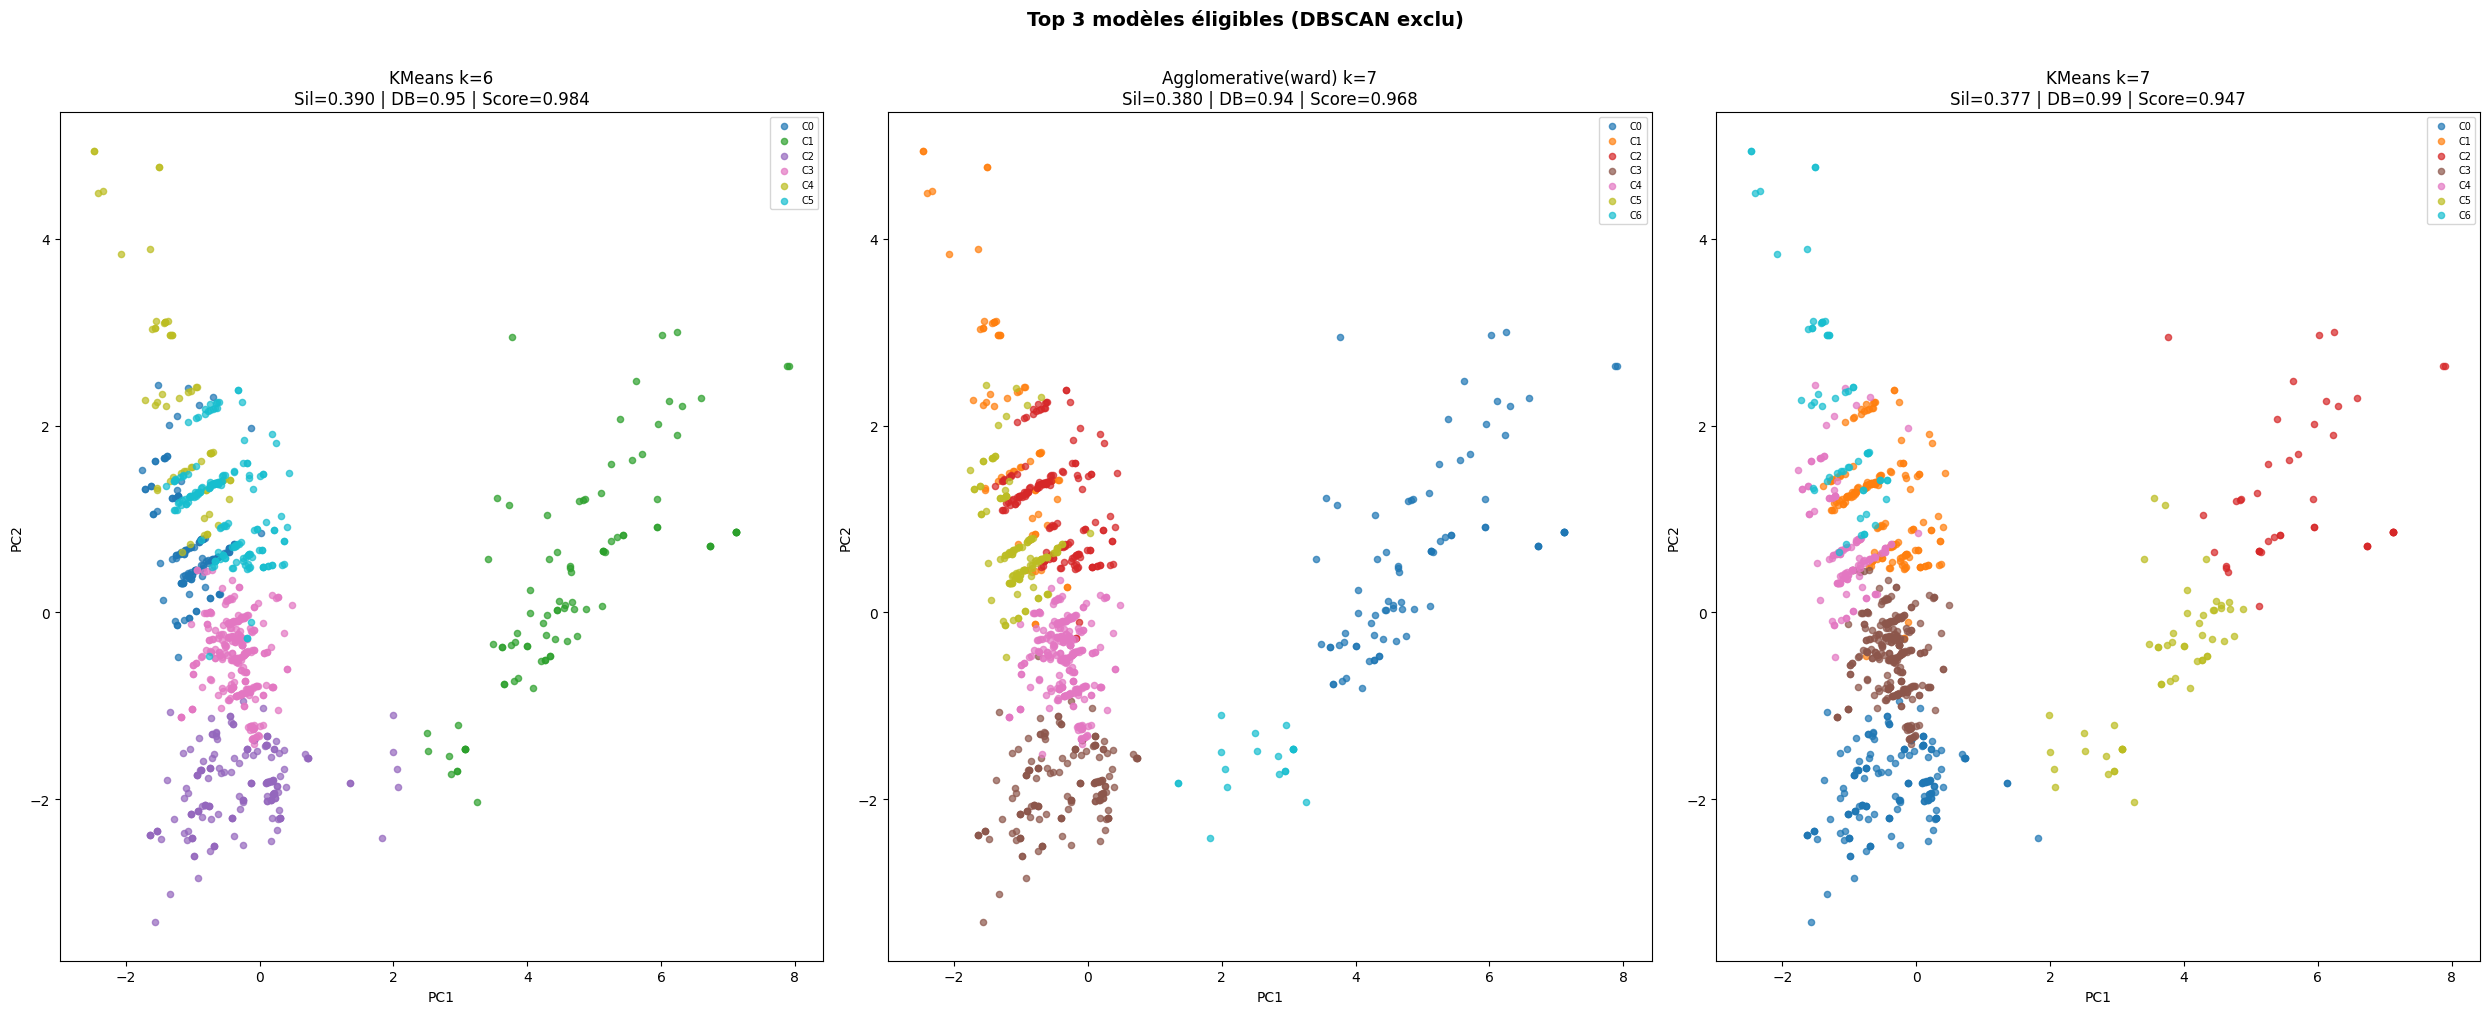

In [21]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Réduction PCA 2D pour visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"Variance expliquée par les 2 composantes PCA : {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Afficher les 3 meilleurs modèles ÉLIGIBLES (DBSCAN exclu)
top3 = eligible_df.head(3)
print(f"Top 3 modèles éligibles : {list(top3['Modèle'])}")

fig, axes = plt.subplots(1, 3, figsize=(25, 10))
for ax, (_, row) in zip(axes, top3.iterrows()):
    labels = row['labels']
    unique_labels = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    for i, lab in enumerate(unique_labels):
        mask = labels == lab
        if lab == -1:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c='lightgray',
                       alpha=0.4, marker='x', s=20, label='Outliers')
        else:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[colors[i]],
                       alpha=0.7, s=20, label=f'C{lab}')
    score_str = f" | Score={row['score_composite']:.3f}" if 'score_composite' in row else ""
    ax.set_title(f"{row['Modèle']}\nSil={row['Silhouette↑']:.3f} | DB={row['Davies-Bouldin↓']:.2f}{score_str}")
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=7)


plt.suptitle("Top 3 modèles éligibles (DBSCAN exclu)", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Analyse du meilleur modèle : caractéristiques moyennes par cluster et distribution des prix

✅ Nokia T21 supprimé de l'analyse (1 ligne(s))
Segments détectés : {np.int64(0): 'Essentiel', np.int64(1): 'Confort', np.int64(2): 'Performance', np.int64(3): 'Tablettes', np.int64(4): 'Expert', np.int64(5): 'Pro'}
  → Tablettes (écran > 7") : clusters [3]

=== Caractéristiques moyennes par cluster (KMeans k=6) ===


,,RAM_GB,FrontCam_MP,BackCam_MP,Battery_mAh,Screen_inch,Price_USD,n_phones
Cluster_ord,Segment,,,,,,,
0,Essentiel,6.6,13.0,53.5,4849.2,6.6,474.6,295
1,Confort,4.5,9.4,12.8,4063.2,6.4,502.9,171
2,Performance,8.0,36.7,53.8,4553.0,6.6,512.4,128
3,Tablettes,7.0,8.3,14.9,8207.2,11.4,554.0,93
4,Expert,10.5,29.8,129.3,5076.9,6.8,680.1,61
5,Pro,12.6,23.3,50.5,4900.3,6.8,926.4,166



=== Téléphones par cluster (marque, modèle, specs, prix) ===

--- [Essentiel] : 295 appareils | Prix $130 – $2699 (moy $475) ---


,Company Name,Model Name,RAM_GB,FrontCam_MP,BackCam_MP,Battery_mAh,Screen_inch,Price_USD
0,Realme,C61 128GB,4,8,50,5000,6.50,130.0
1,Nokia,C32 64GB,3,8,50,5000,6.52,139.0
2,Infinix,Hot 10T 128GB,4,8,48,5000,6.82,149.0
3,POCO,C65 64GB,4,5,50,5000,6.50,149.0
4,Tecno,Spark 30C 128GB,4,16,50,5000,6.60,149.0
...,...,...,...,...,...,...,...,...
290,Apple,iPhone 14 Pro Max 256GB,8,12,48,4500,6.70,1299.0
291,Apple,iPhone 14 Pro Max 512GB,8,12,48,4500,6.70,1399.0
292,Apple,iPhone 15 Pro Max 512GB,8,12,48,4500,6.70,1399.0
293,Huawei,Mate Xs 2,8,10,50,4600,7.80,2499.0



--- [Confort] : 171 appareils | Prix $79 – $1399 (moy $503) ---


...

,Company Name,Model Name,RAM_GB,FrontCam_MP,BackCam_MP,Battery_mAh,Screen_inch,Price_USD
0,Samsung,Galaxy Tab E 10.1 16GB,1,2,5,5000,10.1,129.0
1,Honor,Pad X8a Kids Edition,3,2,5,5100,9.7,129.0
2,Honor,Pad X8 Lite,3,2,5,5000,9.7,149.0
3,Honor,Pad X8a,4,2,5,5000,9.7,149.0
4,Honor,Pad X6,3,2,5,5100,9.7,159.0
...,...,...,...,...,...,...,...,...
88,Samsung,Galaxy Tab S9 Ultra 256GB,12,12,13,11200,14.6,1199.0
89,Apple,iPad Pro 12.9-inch 512GB,6,7,12,9720,12.9,1299.0
90,Apple,iPad Pro 13-inch 512GB,6,7,12,10307,13.0,1399.0
91,Apple,iPad Pro 13-inch 1TB,6,7,12,10307,13.0,1599.0



--- [Expert] : 61 appareils | Prix $199 – $1499 (moy $680) ---


,Company Name,Model Name,RAM_GB,FrontCam_MP,BackCam_MP,Battery_mAh,Screen_inch,Price_USD
0,Oppo,K11x 128GB,8,16,108,5000,6.72,199.0
1,Oppo,K11x 256GB,12,16,108,5000,6.72,229.0
2,Infinix,Hot 40 Pro,8,32,108,5000,6.78,229.0
3,Infinix,Note 40,8,32,108,5000,6.78,279.0
4,OnePlus,OnePlus Nord CE 3 Lite 128GB,8,16,108,5000,6.72,299.0
...,...,...,...,...,...,...,...,...
56,Samsung,Galaxy Note 20 Ultra 256GB,12,10,108,4500,6.90,1399.0
57,Samsung,Galaxy W21 5G 256GB,12,10,108,4500,7.60,1399.0
58,Samsung,Galaxy W22 5G 256GB,12,10,108,4500,7.60,1499.0
59,Motorola,Edge 50 Ultra 512GB,12,60,200,5000,6.90,1499.0



--- [Pro] : 166 appareils | Prix $270 – $2799 (moy $926) ---


,Company Name,Model Name,RAM_GB,FrontCam_MP,BackCam_MP,Battery_mAh,Screen_inch,Price_USD
0,Realme,P1 Speed 5G 256GB,12,16,64,5100,6.70,270.0
1,Oppo,K10 5G 256GB,12,16,64,5000,6.59,279.0
2,Realme,P1 Pro 5G 256GB,12,16,64,5200,6.70,290.0
3,Oppo,Reno3 5G 256GB,12,32,64,4025,6.40,299.0
4,Oppo,K11 256GB,12,16,64,5000,6.70,299.0
...,...,...,...,...,...,...,...,...
161,Samsung,Galaxy Z Fold6 1TB,12,10,50,4400,7.60,2259.0
162,Huawei,Mate X3,12,8,50,4800,7.85,2499.0
163,Huawei,Mate X6,12,8,50,4800,7.93,2499.0
164,Huawei,Mate XT 256GB,12,13,50,5000,7.92,2599.0


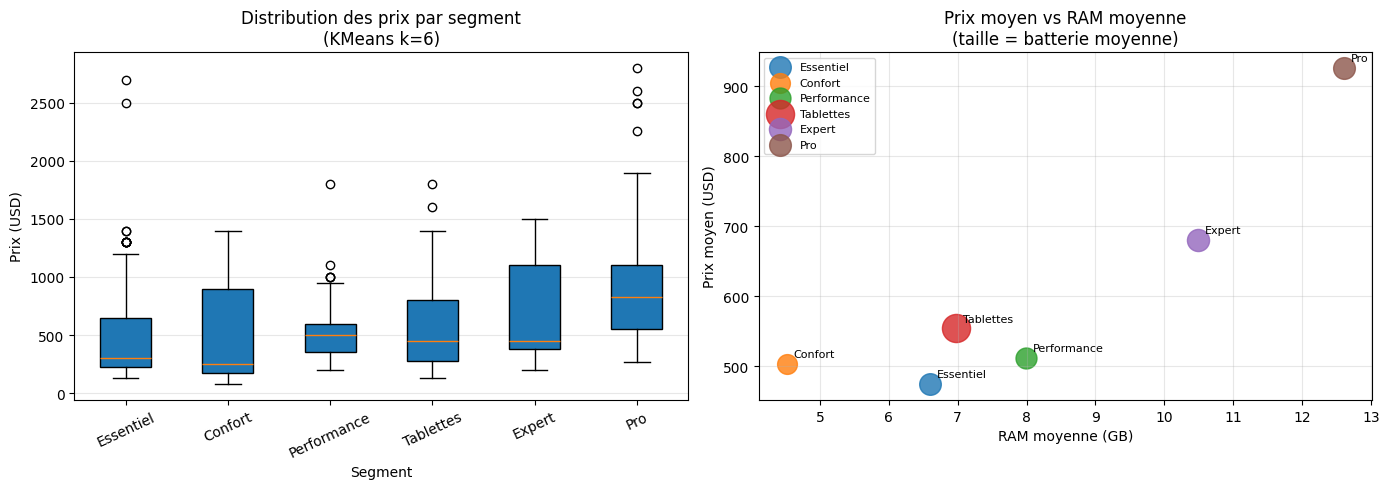

In [22]:
# Appliquer le meilleur modèle sur le dataframe
best_labels = best['labels']
df_analysis = df.copy()
df_analysis['Cluster'] = best_labels

# Exclure outliers DBSCAN si besoin
df_clean = df_analysis[df_analysis['Cluster'] != -1].copy()

# --- Suppression des entrées incorrectes ---
before = len(df_clean)
df_clean = df_clean[~(
    (df_clean['Company Name'].str.lower().str.strip() == 'nokia') &
    (df_clean['Model Name'].str.lower().str.contains('t21'))
)].reset_index(drop=True)
if before - len(df_clean) > 0:
    print(f"✅ Nokia T21 supprimé de l'analyse ({before - len(df_clean)} ligne(s))")

# --- Nommage intelligent des segments ---
# 1. Ordonner par prix moyen croissant
price_order_analysis = (
    df_clean.groupby('Cluster')['Price_USD'].mean()
    .sort_values().reset_index()
)
price_order_analysis['Cluster_label'] = range(len(price_order_analysis))
cluster_map_analysis = dict(zip(price_order_analysis['Cluster'], price_order_analysis['Cluster_label']))
df_clean['Cluster_ord'] = df_clean['Cluster'].map(cluster_map_analysis)

# 2. Détecter le cluster "Tablettes" par taille d'écran moyenne (> 7.0 pouces)
screen_by_cluster = df_clean.groupby('Cluster_ord')['Screen_inch'].mean()
tablet_clusters = screen_by_cluster[screen_by_cluster > 7.0].index.tolist()

# 3. Noms des segments phones (sans tablettes), ordonnés par prix
n_cl = int(best['n_clusters'])
n_phones_clusters = n_cl - len(tablet_clusters)
phone_noms = {
    1: ['Essentiel'],
    2: ['Essentiel', 'Performance'],
    3: ['Essentiel', 'Confort', 'Performance'],
    4: ['Essentiel', 'Confort', 'Performance', 'Expert'],
    5: ['Essentiel', 'Confort', 'Performance', 'Expert', 'Pro'],
    6: ['Essentiel', 'Confort', 'Performance', 'Expert', 'Pro', 'Ultra Pro'],
}
phone_labels = phone_noms.get(n_phones_clusters, [f'Tier {i+1}' for i in range(n_phones_clusters)])

# 4. Assigner les noms
phone_label_iter = iter(phone_labels)
segment_map = {}
for c in sorted(df_clean['Cluster_ord'].unique()):
    if c in tablet_clusters:
        segment_map[c] = 'Tablettes'
    else:
        segment_map[c] = next(phone_label_iter)

df_clean['Segment'] = df_clean['Cluster_ord'].map(segment_map)
print(f"Segments détectés : {segment_map}")
print(f"  → Tablettes (écran > 7\") : clusters {tablet_clusters}")

# --- Caractéristiques moyennes par cluster ---
feat_display = ['RAM_GB', 'FrontCam_MP', 'BackCam_MP', 'Battery_mAh', 'Screen_inch', 'Price_USD']
cluster_stats = df_clean.groupby(['Cluster_ord', 'Segment'])[feat_display].mean().round(1)
cluster_stats['n_phones'] = df_clean.groupby(['Cluster_ord', 'Segment']).size()
print(f"\n=== Caractéristiques moyennes par cluster ({best['Modèle']}) ===")
display(cluster_stats)

# --- Liste des téléphones par cluster ---
print(f"\n=== Téléphones par cluster (marque, modèle, specs, prix) ===")
clusters_sorted = sorted(df_clean['Cluster_ord'].unique())
for c in clusters_sorted:
    sub = df_clean[df_clean['Cluster_ord'] == c].copy()
    seg_name = sub['Segment'].iloc[0]
    cols_show = ['Company Name', 'Model Name', 'RAM_GB', 'FrontCam_MP', 'BackCam_MP', 'Battery_mAh', 'Screen_inch', 'Price_USD']
    sub_sorted = sub[cols_show].sort_values('Price_USD').reset_index(drop=True)
    prix_min = sub['Price_USD'].min()
    prix_max = sub['Price_USD'].max()
    prix_moy = sub['Price_USD'].mean()
    print(f"\n--- [{seg_name}] : {len(sub)} appareils | Prix ${prix_min:.0f} – ${prix_max:.0f} (moy ${prix_moy:.0f}) ---")
    display(sub_sorted)

# --- Distribution des prix ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

data_box = [df_clean[df_clean['Cluster_ord'] == c]['Price_USD'].dropna().values for c in clusters_sorted]
seg_labels_plot = [df_clean[df_clean['Cluster_ord'] == c]['Segment'].iloc[0] for c in clusters_sorted]
ax1.boxplot(data_box, labels=seg_labels_plot, patch_artist=True)
ax1.set_title(f'Distribution des prix par segment\n({best["Modèle"]})')
ax1.set_xlabel('Segment')
ax1.set_ylabel('Prix (USD)')
ax1.tick_params(axis='x', rotation=25)
ax1.grid(axis='y', alpha=0.3)

for c in clusters_sorted:
    sub = df_clean[df_clean['Cluster_ord'] == c]
    seg_name = sub['Segment'].iloc[0]
    ax2.scatter(sub['RAM_GB'].mean(), sub['Price_USD'].mean(),
                s=sub['Battery_mAh'].mean() / 20, alpha=0.8, label=seg_name)
    ax2.annotate(seg_name, (sub['RAM_GB'].mean(), sub['Price_USD'].mean()),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)
ax2.set_title('Prix moyen vs RAM moyenne\n(taille = batterie moyenne)')
ax2.set_xlabel('RAM moyenne (GB)')
ax2.set_ylabel('Prix moyen (USD)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## Export pour l'application Streamlit

On sauvegarde le dataset cloné avec les labels du meilleur modèle dans `phones_clustered.csv`, utilisé directement par `app.py`.


In [23]:
import os

# --- Construire le dataframe complet avec cluster assigné ---
df_export = df.copy()
df_export['Cluster'] = best['labels']

# --- Suppression des entrées incorrectes ---
before = len(df_export)
df_export = df_export[~(
    (df_export['Company Name'].str.lower().str.strip() == 'nokia') &
    (df_export['Model Name'].str.lower().str.contains('t21'))
)].reset_index(drop=True)
print(f"✅ Nokia T21 supprimé ({before - len(df_export)} ligne(s) retirée(s))")

# --- Ordonner les clusters par prix moyen croissant ---
price_order = (
    df_export.groupby('Cluster')['Price_USD']
    .mean().sort_values().reset_index()
)
price_order['Cluster_label'] = range(len(price_order))
cluster_map = dict(zip(price_order['Cluster'], price_order['Cluster_label']))
df_export['Cluster'] = df_export['Cluster'].map(cluster_map)

# --- Détecter le cluster "Tablettes" par taille d'écran moyenne (> 7.0 pouces) ---
screen_by_cluster = df_export.groupby('Cluster')['Screen_inch'].mean()
tablet_clusters = screen_by_cluster[screen_by_cluster > 7.0].index.tolist()

# --- Nommer les segments phones (hors tablettes), ordonnés par prix ---
n_cl = int(best['n_clusters'])
n_phones_clusters = n_cl - len(tablet_clusters)
phone_noms = {
    1: ['Essentiel'],
    2: ['Essentiel', 'Performance'],
    3: ['Essentiel', 'Confort', 'Performance'],
    4: ['Essentiel', 'Confort', 'Performance', 'Expert'],
    5: ['Essentiel', 'Confort', 'Performance', 'Expert', 'Pro'],
    6: ['Essentiel', 'Confort', 'Performance', 'Expert', 'Pro', 'Ultra Pro'],
}
phone_labels = phone_noms.get(n_phones_clusters, [f'Tier {i+1}' for i in range(n_phones_clusters)])

phone_label_iter = iter(phone_labels)
segment_map = {}
for c in sorted(df_export['Cluster'].unique()):
    if c in tablet_clusters:
        segment_map[c] = 'Tablettes'
    else:
        segment_map[c] = next(phone_label_iter)

df_export['Segment'] = df_export['Cluster'].map(segment_map)
print(f"✅ Segments détectés : {segment_map}")
print(f"   → Tablettes (écran moy > 7\") : clusters {tablet_clusters}")

# --- Exporter ---
output_path = 'phones_clustered.csv'
df_export.to_csv(output_path, index=False)
print(f"\n✅ Exporté : {output_path} ({len(df_export)} lignes, {n_cl} clusters)")
print(f"   Modèle utilisé : {best['Modèle']}")
print(f"\nRépartition par segment :")
display(df_export.groupby(['Cluster', 'Segment']).agg(
    n_appareils=('Model Name', 'count'),
    prix_moy=('Price_USD', 'mean'),
    ecran_moy=('Screen_inch', 'mean')
).round(1).reset_index())


✅ Nokia T21 supprimé (1 ligne(s) retirée(s))
✅ Segments détectés : {np.int64(0): 'Essentiel', np.int64(1): 'Confort', np.int64(2): 'Performance', np.int64(3): 'Tablettes', np.int64(4): 'Expert', np.int64(5): 'Pro'}
   → Tablettes (écran moy > 7") : clusters [3]

✅ Exporté : phones_clustered.csv (914 lignes, 6 clusters)
   Modèle utilisé : KMeans k=6

Répartition par segment :


,Cluster,Segment,n_appareils,prix_moy,ecran_moy
0,0,Essentiel,295,474.6,6.6
1,1,Confort,171,502.9,6.4
2,2,Performance,128,512.4,6.6
3,3,Tablettes,93,554.0,11.4
4,4,Expert,61,680.1,6.8
5,5,Pro,166,926.4,6.8
